In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df.head(5) # Checking the first 5 rows in the dataset

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month

df = df.drop(columns=['date']) #dataset w/o the column date

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,weekday,month
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,11,0,1
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,11,0,1
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,11,0,1
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,11,0,1
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,11,0,1


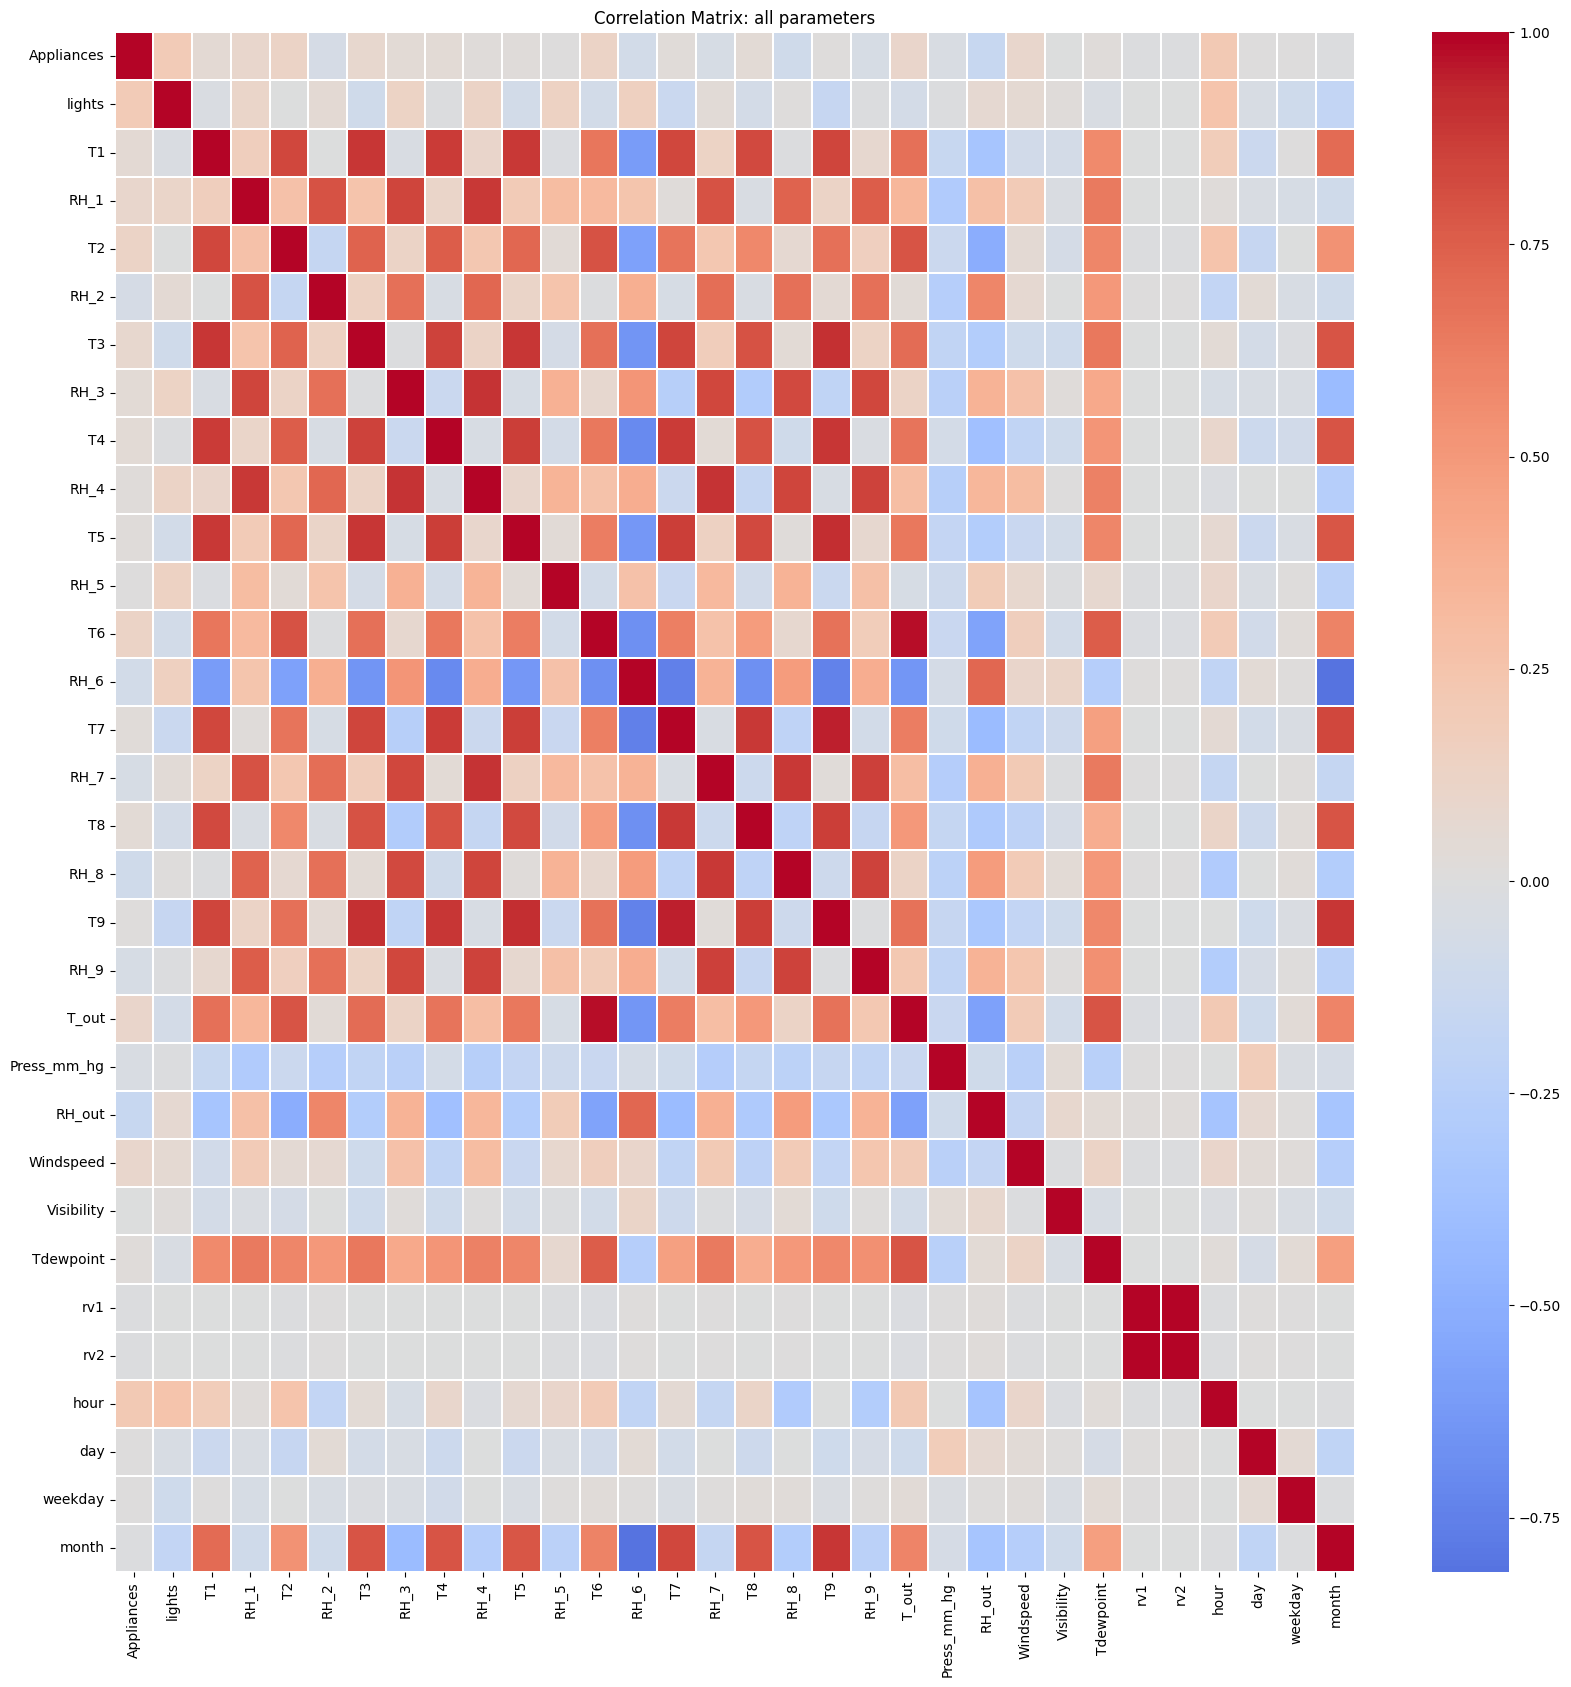

In [4]:
#MATRICE DI CORRELAZIONE CON TUTTO
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(20,20))
sns.heatmap(
    corr_matrix,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Matrix: all parameters")
plt.show()

#ogni quadrato mostra la correlazione tra due variabili. Il valore dentro ogni cella è un numero tra:
#+1 → correlazione positiva(quando una var aumenta, l'altra var aumenta)
#0 → nessuna correlazione
#−1 → correlazione negativa (quando una var aumenta, l'altra var diminuisce)

In [5]:
#l'idea è avanzare eliminando ciò che ha meno correlazione con l'utilizzo di energia 
#T1–T9 (temp) sono molto correlati tra loro, Quando aumenta la temperatura generale, aumenta ovunque
#RH_1–RH_9 (umidità) anche, 
#rv1 e rv2 dovrebbero avere correlazioni vicine a 0, sono rumore

#correlazioni con Appliances 
corr = df.corr()
corr_target = corr["Appliances"].sort_values(ascending=False)

print(corr_target)

Appliances     1.000000
hour           0.216792
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
weekday        0.003060
day            0.002366
Visibility     0.000230
rv2           -0.011145
rv1           -0.011145
month         -0.011606
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


In [6]:
#BUILDING REGRESSION MODELS

#creo una copia del df
df1 = df

X = df1.drop("Appliances", axis=1) #dataset senza appliances
y = df1["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
#SPLIT DATA FOR TRAINING AND TESTING (TRAINING 80%, TESTING 20%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

In [8]:
#COSTRUISCO RANDOM FOREST (tutti i parametri)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100, #forest of 100 decision trees 
    max_depth=15,  #max depth of trees, no depth can do overfitting 
    random_state=0 #random seed,ensures the results are reproducible
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=0)

In [9]:
#PREDICTIONS
y_pred = rf.predict(X_test)

In [10]:
#VALUTO IL MODELLO
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred) #errore medio (mean absolute error)

mse = mean_squared_error(y_test, y_pred) #errore quadratico ( mean squared error)

rmse = np.sqrt(mse) #errore reale interpretabile (root mean squared error)

r2 = r2_score(y_test, y_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae) 
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 37.50549526402191
MSE: 6086.632567464086
RMSE: 78.0168736073427
R2 Score: 0.4657140822315655


In [11]:
#MAE ≈ 37 → errore medio ≈ 37 Wh
#RMSE ≈ 78 → errore tipico ≈ 78 Wh
#R² ≈ 0.47 → il modello spiega 47% della variabilità
#Per questo dataset, con tutte le variabili, un R² tra 0.45 e 0.60 è normale.
#Ora l'obiettivo è: AUMENTARE R², diminuire rmse eliminando le variabili inutili alla nostra predizione

In [12]:
#METODO: FEATURE SELECTION
df2 = df
#tolgo le var che sono meno correlate: rv1 rv2 day weekday month and pressure, Visibility
df2 = df2.drop(columns=['rv1', 'rv2', 'day', 'weekday', 'month', 'Press_mm_hg', 'Visibility'])

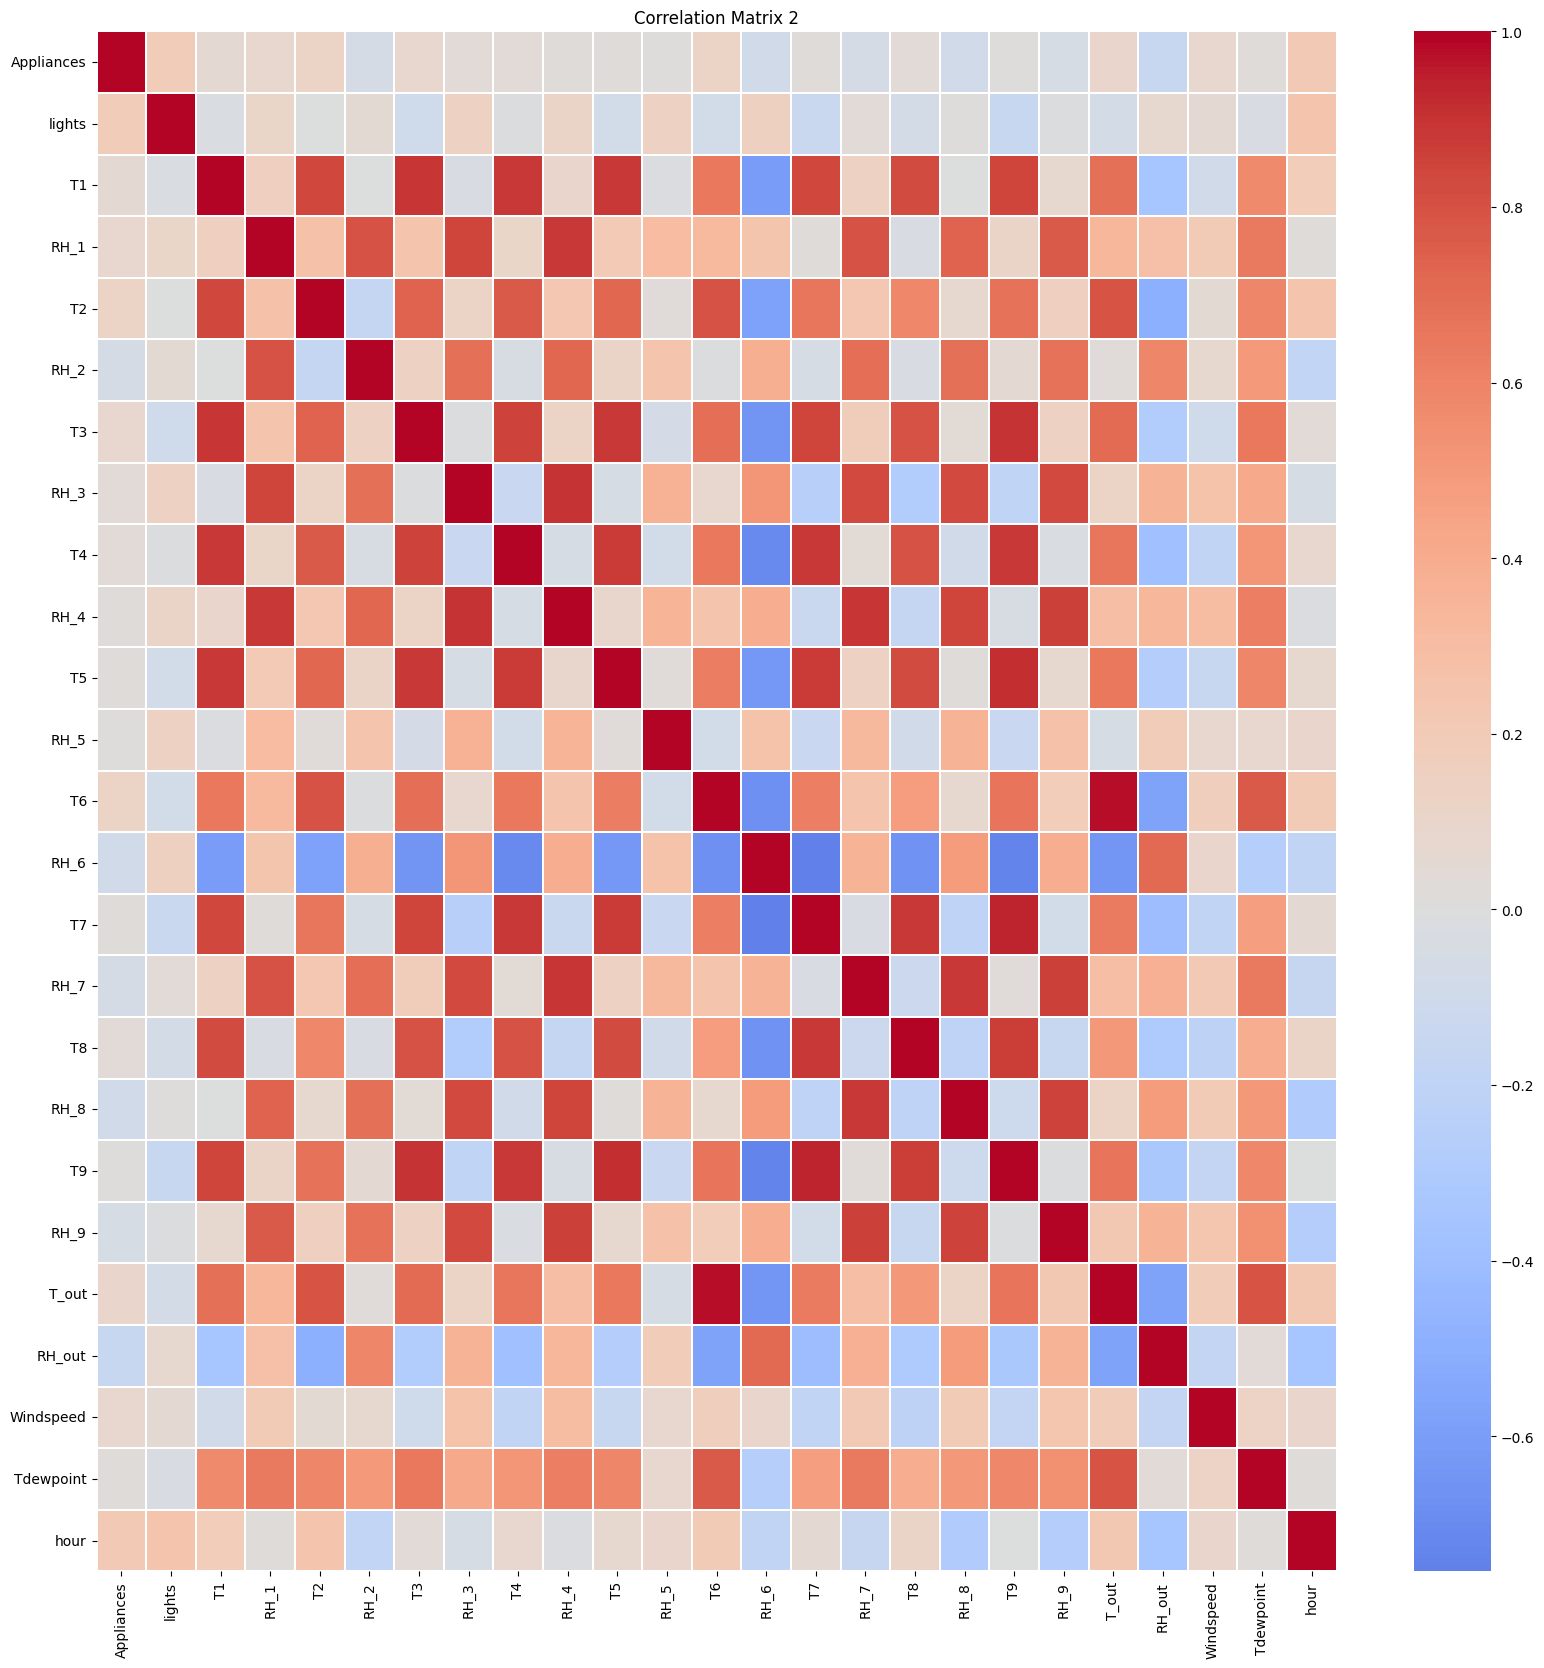

In [13]:
corr_matrix2 = df2.corr()

plt.figure(figsize=(20,20))
sns.heatmap(
    corr_matrix2,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Matrix 2")
plt.show()

In [14]:
#ripeto il procedimento

#BUILDING REGRESSION MODELS
X2 = df2.drop("Appliances", axis=1) #dataset senza appliances
y2 = df2["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=0)

rf2 = RandomForestRegressor(
    n_estimators=100, #forest of 100 decision trees 
    max_depth=15,  #max depth of trees, no depth can do overfitting 
    random_state=0 #random seed,ensures the results are reproducible
)
rf2.fit(X2_train, y2_train)

RandomForestRegressor(max_depth=15, random_state=0)

In [15]:
#PREDICTIONS
y2_pred = rf2.predict(X2_test)

#VALUTO IL MODELLO

mae2 = mean_absolute_error(y2_test, y2_pred) #errore medio (mean absolute error)

mse2 = mean_squared_error(y2_test, y2_pred) #errore quadratico ( mean squared error)

rmse2 = np.sqrt(mse2) #errore reale interpretabile (root mean squared error)

r22 = r2_score(y2_test, y2_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae2) 
print("MSE:", mse2)
print("RMSE:", rmse2)
print("R2 Score:", r22)

#MAE ≈ 37 → errore medio ≈ 37 Wh
#RMSE ≈ 78 → errore tipico ≈ 78 Wh
#R² ≈ 0.45 → il modello spiega 45% della variabilità

# - modello peggiorato leggermente

MAE: 37.65915366054693
MSE: 6218.203873977781
RMSE: 78.85558873014506
R2 Score: 0.4541647246067222


In [16]:
corr = df2.corr()
corr_targetT = corr["T1"].sort_values(ascending=False)

print(corr_targetT)

T1            1.000000
T3            0.892402
T5            0.885247
T4            0.877001
T9            0.844777
T7            0.838705
T2            0.836834
T8            0.825413
T_out         0.682846
T6            0.654769
Tdewpoint     0.571309
hour          0.178858
RH_1          0.164006
RH_7          0.135182
RH_4          0.097861
RH_9          0.071756
Appliances    0.055447
RH_2         -0.002509
RH_8         -0.006441
RH_5         -0.014782
lights       -0.023528
RH_3         -0.028550
Windspeed    -0.087654
RH_out       -0.345481
RH_6         -0.615045
Name: T1, dtype: float64


In [17]:
corr = df2.corr()
corr_targetRH = corr["RH_1"].sort_values(ascending=False)

print(corr_targetRH)

RH_1          1.000000
RH_4          0.880359
RH_3          0.844677
RH_7          0.801122
RH_2          0.797535
RH_9          0.764001
RH_8          0.736196
Tdewpoint     0.639106
T_out         0.340767
T6            0.316141
RH_5          0.303258
RH_out        0.274126
T2            0.269839
T3            0.253230
RH_6          0.245126
T5            0.205797
Windspeed     0.204932
T1            0.164006
T9            0.115263
lights        0.106968
T4            0.106180
Appliances    0.086031
T7            0.021397
hour          0.018594
T8           -0.030053
Name: RH_1, dtype: float64


In [18]:
#visto che tutte le rh e tutte le temp sono correlate altamente fra loro creo un unica
#umidità e un unica temperatura nella casa, rimangono separate T_out e RH_out

df3 = df2

T_columns = [
    "T1","T2","T3","T4","T5",
    "T6","T7","T8","T9"
]

df3["T_mean"] = df3[T_columns].mean(axis=1)

RH_columns = [
    "RH_1","RH_2","RH_3","RH_4",
    "RH_5","RH_6","RH_7","RH_8",
    "RH_9"
]

df3["RH_mean"] = df3[RH_columns].mean(axis=1)

# Drop temperature interne
df3 = df3.drop(columns=T_columns)

# Drop umidità interne
df3 = df3.drop(columns=RH_columns)

In [19]:
X3 = df3.drop("Appliances", axis=1) #dataset senza appliances
y3 = df3["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42
)


rf3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf3.fit(X3_train, y3_train)

y3_pred = rf3.predict(X3_test)

mae3 = mean_absolute_error(y3_test, y3_pred) #errore medio (mean absolute error)

mse3 = mean_squared_error(y3_test, y3_pred) #errore quadratico ( mean squared error)

rmse3 = np.sqrt(mse3) #errore reale interpretabile (root mean squared error)

r23 = r2_score(y3_test, y3_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae3) 
print("MSE:", mse3)
print("RMSE:", rmse3)
print("R2 Score:", r23)

#risultato migliorato 
#MAE ≈ 32.9 → errore medio ≈ 32 Wh
#RMSE ≈ 67 → errore tipico ≈ 67 Wh
#R² ≈ 0.55 → il modello spiega 55% della variabilità

MAE: 32.890980491512536
MSE: 4519.748662275146
RMSE: 67.22907601830585
R2 Score: 0.5483454062932569


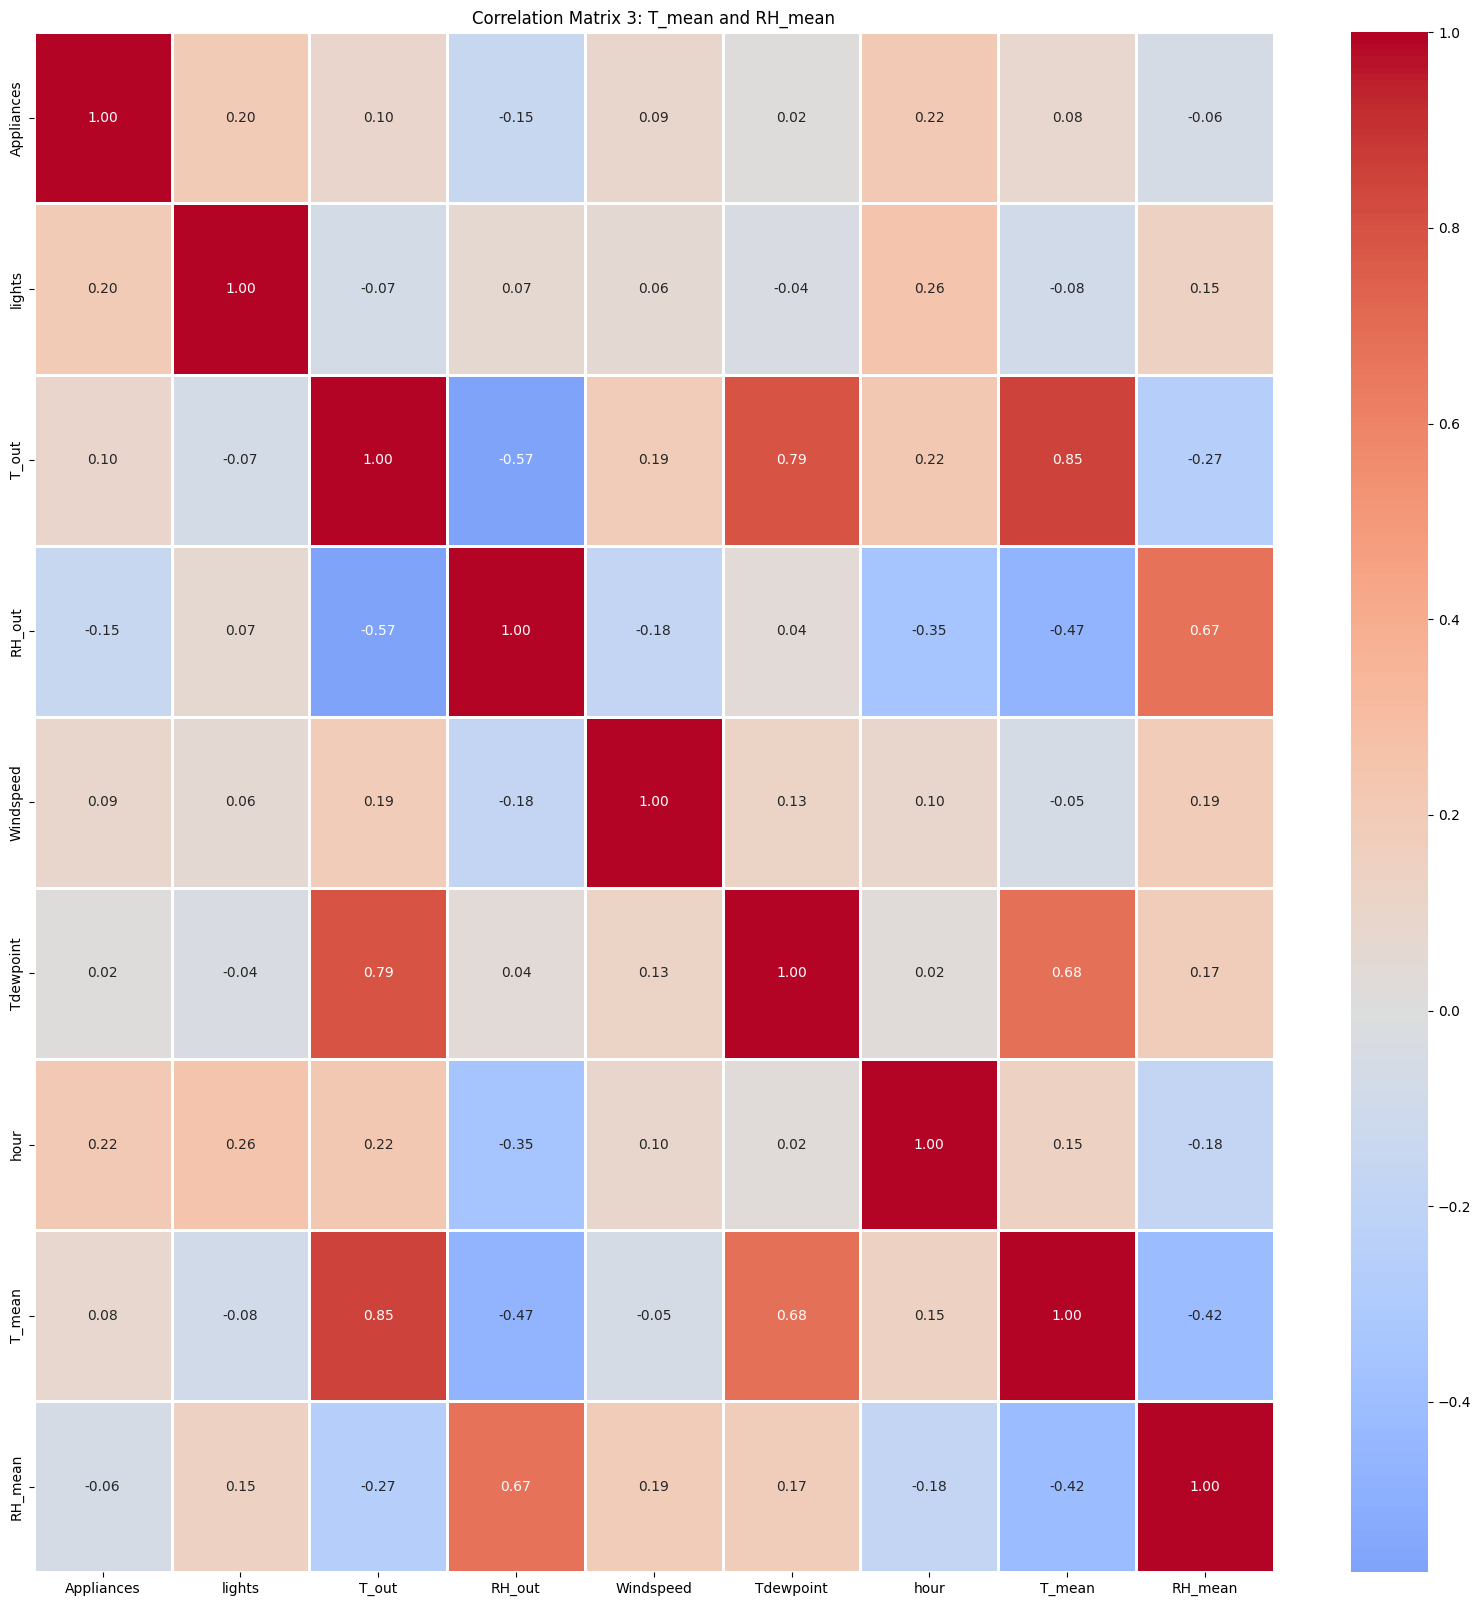

In [20]:
corr_matrix3 = df3.corr()

plt.figure(figsize=(20,20))
sns.heatmap(
    corr_matrix3,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1
)

plt.title("Correlation Matrix 3: T_mean and RH_mean")
plt.show()


In [21]:
corr = df3.corr()
corr_target2 = corr["Appliances"].sort_values(ascending=False)

print(corr_target2)

Appliances    1.000000
hour          0.216792
lights        0.197278
T_out         0.099155
Windspeed     0.087122
T_mean        0.078247
Tdewpoint     0.015353
RH_mean      -0.060228
RH_out       -0.152282
Name: Appliances, dtype: float64


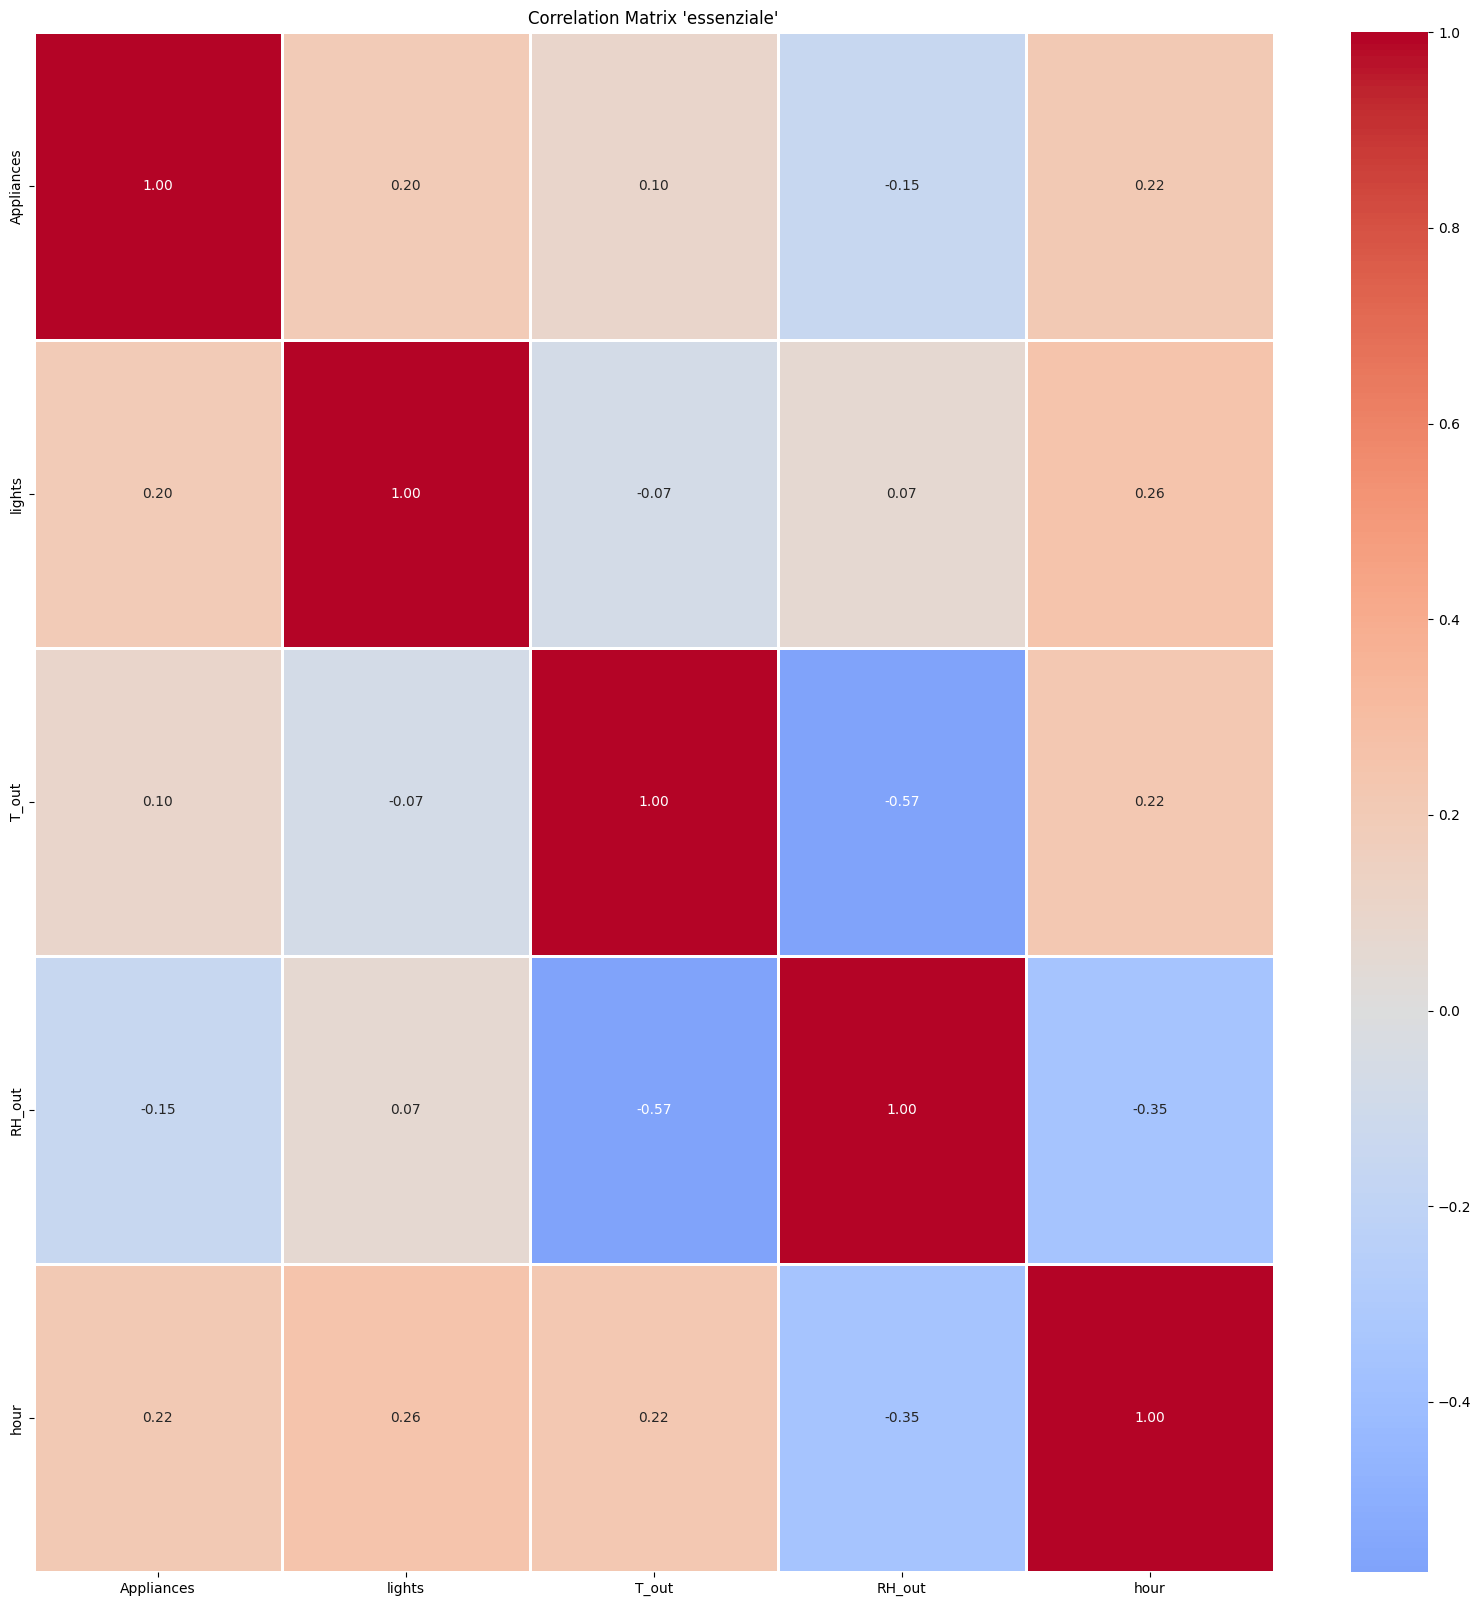

In [22]:
#La matrice di correlazione diventa sempre più chiara.
#Possiamo individuare ulteriori variabili 'futili'
#notiamo che appliances ha correlazione quasi nulla con la T.punto di rugiada
#ha poca correlazione con la temperatura interna media, umidità interna media e velocità del vento
#Interessante è notare che ha una forte correlazione con l'ora della giornata e con le luci, 
#e poi abbastanza con la temperatura esterna.
#ed ha una correlazione negativa con l'umidità fuori (L'umidità è generalmente più alta durante la notte e nelle prime ore del mattino)

df4 = df3.drop(columns=['T_mean', 'RH_mean', 'Tdewpoint', 'Windspeed'])

corr_matrix4 = df4.corr()

plt.figure(figsize=(20,20))
sns.heatmap(
    corr_matrix4,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1
)

plt.title("Correlation Matrix 'essenziale'")
plt.show()


In [23]:
corr = df4.corr()
corr_target4 = corr["Appliances"].sort_values(ascending=False)

print(corr_target4)

Appliances    1.000000
hour          0.216792
lights        0.197278
T_out         0.099155
RH_out       -0.152282
Name: Appliances, dtype: float64


In [24]:
#Possiamo arrivare alla conclusione che l'utilizzo maggiore di energia è dato dal consumo delle luci durante il giorno, i dati 
#indicano il consumo è correlato all'ora della giornata, ci sono ore del giorno in cui viene consumato di più (luci ed elettrodomestici0). 
#possiamo assumere che cè poco consumo di notte, perchè le luci sono spente. 
#l'umidità è più alta nelle notte invernali, la correlazione negativa con il consumo ci dice più è bassa l'umidità più alto il consumo
#probabilmente a causa di riscaldamento.

In [25]:
X4 = df4.drop("Appliances", axis=1) #dataset senza appliances
y4 = df4["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
scaler = StandardScaler()
X4_scaled = scaler.fit_transform(X4)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42
)


rf4 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf4.fit(X4_train, y4_train)

y4_pred = rf4.predict(X4_test)

mae4 = mean_absolute_error(y4_test, y4_pred) #errore medio (mean absolute error)

mse4 = mean_squared_error(y4_test, y4_pred) #errore quadratico ( mean squared error)

rmse4 = np.sqrt(mse3) #errore reale interpretabile (root mean squared error)

r24 = r2_score(y4_test, y4_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae4) 
print("MSE:", mse4)
print("RMSE:", rmse4)
print("R2 Score:", r24)

#risultato peggiore 
#MAE ≈ 41 → errore medio ≈ 41 Wh
#RMSE ≈ 67 → errore tipico ≈ 67 Wh
#R² ≈ 0.33 → il modello spiega 33% della variabilità

MAE: 41.88283308983334
MSE: 6671.508333392309
RMSE: 67.22907601830585
R2 Score: 0.33332191436223246


In [26]:
#provo a mantenere le temp e le umidità separate ma tolgo gli altri parametri
df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month

df = df.drop(columns=['date']) #dataset w/o the column date


In [27]:

df4 = df.drop(columns=[ 'Tdewpoint', 'Windspeed','rv1', 'rv2','Press_mm_hg', 'Visibility'])

X4 = df4.drop("Appliances", axis=1) #dataset senza appliances
y4 = df4["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
scaler = StandardScaler()
X4_scaled = scaler.fit_transform(X4)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42
)


rf4 = RandomForestRegressor(
    n_estimators=100,
     max_depth=30,
    random_state=42
)

rf4.fit(X4_train, y4_train)

y4_pred = rf4.predict(X4_test)

mae4 = mean_absolute_error(y4_test, y4_pred) #errore medio (mean absolute error)

mse4 = mean_squared_error(y4_test, y4_pred) #errore quadratico ( mean squared error)

rmse4 = np.sqrt(mse3) #errore reale interpretabile (root mean squared error)

r24 = r2_score(y4_test, y4_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae4) 
print("MSE:", mse4)
print("RMSE:", rmse4)
print("R2 Score:", r24)

#modello MIGLIORE !!
#MAE ≈ 31 → errore medio ≈ 31 Wh
#RMSE ≈ 67 → errore tipico ≈ 67 Wh
#R² ≈ 0.56 → il modello spiega 56% della variabilità

MAE: 30.999456025847635
MSE: 4397.089003006342
RMSE: 67.22907601830585
R2 Score: 0.5606026804717222


In [28]:
df4


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,RH_out,hour,day,weekday,month
0,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,...,18.2000,48.900000,17.033333,45.5300,6.600000,92.000000,17,11,0,1
1,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,...,18.2000,48.863333,17.066667,45.5600,6.483333,92.000000,17,11,0,1
2,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,...,18.2000,48.730000,17.000000,45.5000,6.366667,92.000000,17,11,0,1
3,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,...,18.1000,48.590000,17.000000,45.4000,6.250000,92.000000,17,11,0,1
4,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,...,18.1000,48.590000,17.000000,45.4000,6.133333,92.000000,17,11,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,...,24.7000,50.074000,23.200000,46.7900,22.733333,55.666667,17,27,4,5
19731,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,45.590000,...,24.7000,49.790000,23.200000,46.7900,22.600000,56.000000,17,27,4,5
19732,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,45.730000,...,24.7000,49.660000,23.200000,46.7900,22.466667,56.333333,17,27,4,5
19733,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,45.790000,...,24.6625,49.518750,23.200000,46.8175,22.333333,56.666667,17,27,4,5


In [29]:
corr = df4.corr()
corr_target4 = corr["Appliances"].sort_values(ascending=False)

print(corr_target4)

Appliances    1.000000
hour          0.216792
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
T8            0.039572
RH_3          0.036292
T7            0.025801
T5            0.019760
RH_4          0.016965
T9            0.010010
RH_5          0.006955
weekday       0.003060
day           0.002366
month        -0.011606
RH_9         -0.051462
RH_7         -0.055642
RH_2         -0.060465
RH_6         -0.083178
RH_8         -0.094039
RH_out       -0.152282
Name: Appliances, dtype: float64


In [30]:
#TOLGO DAY MONTH E WEEKDAY

df4 = df.drop(columns=[ 'day', 'month','weekday'])

X4 = df4.drop("Appliances", axis=1) #dataset senza appliances
y4 = df4["Appliances"] #dataset con solo appliances

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
scaler = StandardScaler()
X4_scaled = scaler.fit_transform(X4)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42
)


rf4 = RandomForestRegressor(
    n_estimators=100,
     max_depth=30,
    random_state=42
)

rf4.fit(X4_train, y4_train)

y4_pred = rf4.predict(X4_test)

mae4 = mean_absolute_error(y4_test, y4_pred) #errore medio (mean absolute error)

mse4 = mean_squared_error(y4_test, y4_pred) #errore quadratico ( mean squared error)

rmse4 = np.sqrt(mse3) #errore reale interpretabile (root mean squared error)

r24 = r2_score(y4_test, y4_pred) #come le previsioni del modello corrispondono ai dati reali.1=perfetta corrispondenza, <0=male

print("MAE:", mae4) 
print("MSE:", mse4)
print("RMSE:", rmse4)
print("R2 Score:", r24)

#modello leggermente peggiore
#MAE ≈ 32 → errore medio ≈ 32 Wh
#RMSE ≈ 67 → errore tipico ≈ 67 Wh
#R² ≈ 0.54 → il modello spiega 54% della variabilità

MAE: 32.19066184736987
MSE: 4589.428911462995
RMSE: 67.22907601830585
R2 Score: 0.5413823189651927


In [31]:
#CONCLUSIONE
#eliminare tante variabili non migliora il modello, ma eliminare poche variabili studiate lo può migliorare 